# A. Payments & Order Funnel

Things done in this category:
1. Loading `orders_dataset.csv` and `order_payments_dataset.csv`
2. Cleaning and building the shared output file `orders_master.csv`
3. Exploring the order funnel, delivery timing, and payment patterns
4. Flagging data quality issues found along the way
5. Detailed analysis of growth, timing and payment patterns.

In [1]:
import pandas as pd
pd.set_option('display.width', 150)
pd.set_option('display.max_columns', None)

## 1. Load raw data

In [2]:
orders = pd.read_csv('orders_dataset.csv')
payments = pd.read_csv('order_payments_dataset.csv')

print("orders shape:", orders.shape)
print("payments shape:", payments.shape)

orders shape: (99441, 8)
payments shape: (103886, 5)


In [3]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [4]:
payments.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


## 2. Initial data quality checks (before cleaning)
Quick checks on nulls, duplicates, and payment structure.

In [5]:
print("Null values in Orders")
print(orders.isnull().sum())

Null values in Orders
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64


In [6]:
print("Orders: distribution of order_status")
print(orders['order_status'].value_counts())

Orders: distribution of order_status
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64


In [7]:
print("Distribution in %")
print((orders['order_status'].value_counts(normalize=True) * 100).round(2))

Distribution in %
order_status
delivered      97.02
shipped         1.11
canceled        0.63
unavailable     0.61
invoiced        0.32
processing      0.30
created         0.01
approved        0.00
Name: proportion, dtype: float64


In [8]:
print("Null values in Payments")
print(payments.isnull().sum())

Null values in Payments
order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64


In [9]:
print("Payments: rows per order (where multiple rows means split payments)")
rows_per_order = payments.groupby('order_id').size()
print(rows_per_order.value_counts())

Payments: rows per order (where multiple rows means split payments)
1     96479
2      2382
3       301
4       108
5        52
6        36
7        28
8        11
9         9
11        8
12        8
10        5
13        3
15        2
14        2
19        2
22        1
21        1
26        1
29        1
Name: count, dtype: int64


In [ ]:
print("distribution of payment_type")
print(payments['payment_type'].value_counts())

distribution of payment_type
payment_type
credit_card    76795
boleto         19784
voucher         5775
debit_card      1529
not_defined        3
Name: count, dtype: int64


In [10]:
print("Summary of payment_installments")
print(payments['payment_installments'].describe())

Summary of payment_installments
count    103886.000000
mean          2.853349
std           2.687051
min           0.000000
25%           1.000000
50%           1.000000
75%           4.000000
max          24.000000
Name: payment_installments, dtype: float64


In [12]:
print("Rows with 0 installments:")
print(payments[payments['payment_installments'] == 0])

Rows with 0 installments:
                               order_id  payment_sequential payment_type  payment_installments  payment_value
46982  744bade1fcf9ff3f31d860ace076d422                   2  credit_card                     0          58.69
79014  1a57108394169c0b47d8f876acc9ba2d                   2  credit_card                     0         129.94


In [13]:
print("Rows with payment_type == 'not_defined':")
print(payments[payments['payment_type'] == 'not_defined'])

Rows with payment_type == 'not_defined':
                               order_id  payment_sequential payment_type  payment_installments  payment_value
51280  4637ca194b6387e2d538dc89b124b0ee                   1  not_defined                     1            0.0
57411  00b1cb0320190ca0daa2c88b35206009                   1  not_defined                     1            0.0
94427  c8c528189310eaa44a745b8d9d26908b                   1  not_defined                     1            0.0


## 3. Build `orders_master.csv`
One row per `order_id`. It adds derived timing fields and collapses `order_payments` (which can have
multiple rows per order) down to one row per order.

**Derived timing fields:**
- `approval_hours` : purchase -> payment approval
- `carrier_handoff_days` : approval -> handed to carrier
- `delivery_days` : purchase -> delivered to customer
- `delivery_delay_days` : delivered date minus estimated date (positive = late)


In [15]:
date_cols = ['order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date',
             'order_delivered_customer_date', 'order_estimated_delivery_date']

for c in date_cols:
    orders[c] = pd.to_datetime(orders[c])

orders['approval_hours'] = (orders['order_approved_at'] - orders['order_purchase_timestamp']).dt.total_seconds() / 3600
orders['carrier_handoff_days'] = (orders['order_delivered_carrier_date'] - orders['order_approved_at']).dt.total_seconds() / 86400
orders['delivery_days'] = (orders['order_delivered_customer_date'] - orders['order_purchase_timestamp']).dt.total_seconds() / 86400
orders['delivery_delay_days'] = (orders['order_delivered_customer_date'] - orders['order_estimated_delivery_date']).dt.total_seconds() / 86400

orders['is_delivered'] = orders['order_status'] == 'delivered'
orders['is_canceled'] = orders['order_status'] == 'canceled'
orders['is_late'] = orders['delivery_delay_days'] > 0

orders[['order_id','order_status','approval_hours','carrier_handoff_days','delivery_days','delivery_delay_days','is_late']].head()


,order_id,order_status,approval_hours,carrier_handoff_days,delivery_days,delivery_delay_days,is_late
0,e481f51cbdc54678b7cc49136f2d6af7,delivered,0.178333,2.366493,8.436574,-7.107488,False
1,53cdb2fc8bc7dce0b6741e2150273451,delivered,30.713889,0.462882,13.782037,-5.355729,False
2,47770eb9100c2d0c44946d9cf07ec65d,delivered,0.276111,0.204595,9.394213,-17.245498,False
3,949d5b44dbf5de918fe9c16f97b45f8a,delivered,0.298056,3.745833,13.208750,-12.980069,False
4,ad21c59c0840e6cb83a9ceb5573f8159,delivered,1.030556,0.893113,2.873877,-9.238171,False


In [17]:
# Compressing payments to one row per order
pay_agg = payments.groupby('order_id').agg(
    total_payment_value=('payment_value', 'sum'),
    max_installments=('payment_installments', 'max'),
    n_payment_rows=('payment_sequential', 'count')
).reset_index()

# the dominant payment type is the one contributing the highest payment_value for that order
idx = payments.groupby('order_id')['payment_value'].idxmax()
dominant = payments.loc[idx, ['order_id', 'payment_type']].rename(columns={'payment_type': 'payment_type_primary'})
pay_agg = pay_agg.merge(dominant, on='order_id', how='left')

pay_agg.head()

,order_id,total_payment_value,max_installments,n_payment_rows,payment_type_primary
0,00010242fe8c5a6d1ba2dd792cb16214,72.19,2,1,credit_card
1,00018f77f2f0320c557190d7a144bdd3,259.83,3,1,credit_card
2,000229ec398224ef6ca0657da4fc703e,216.87,5,1,credit_card
3,00024acbcdf0a6daa1e931b038114c75,25.78,2,1,credit_card
4,00042b26cf59d7ce69dfabb4e55b4fd9,218.04,3,1,credit_card


In [18]:
orders_master = orders.rename(columns={
    'order_purchase_timestamp': 'purchase_ts',
    'order_approved_at': 'approved_ts',
    'order_delivered_carrier_date': 'carrier_ts',
    'order_delivered_customer_date': 'delivered_ts',
    'order_estimated_delivery_date': 'estimated_delivery_ts'
}).merge(pay_agg, on='order_id', how='left')

cols = ['order_id', 'customer_id', 'order_status', 'purchase_ts', 'approved_ts', 'carrier_ts', 'delivered_ts',
        'estimated_delivery_ts', 'approval_hours', 'carrier_handoff_days', 'delivery_days', 'delivery_delay_days',
        'is_delivered', 'is_canceled', 'is_late', 'total_payment_value', 'payment_type_primary',
        'max_installments', 'n_payment_rows']
orders_master = orders_master[cols]

print("Final shape:", orders_master.shape)
orders_master.head()


Final shape: (99441, 19)


,order_id,customer_id,order_status,purchase_ts,approved_ts,carrier_ts,delivered_ts,estimated_delivery_ts,approval_hours,carrier_handoff_days,delivery_days,delivery_delay_days,is_delivered,is_canceled,is_late,total_payment_value,payment_type_primary,max_installments,n_payment_rows
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,0.178333,2.366493,8.436574,-7.107488,True,False,False,38.71,voucher,1.0,3.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,30.713889,0.462882,13.782037,-5.355729,True,False,False,141.46,boleto,1.0,1.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,0.276111,0.204595,9.394213,-17.245498,True,False,False,179.12,credit_card,3.0,1.0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,0.298056,3.745833,13.208750,-12.980069,True,False,False,72.20,credit_card,1.0,1.0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,1.030556,0.893113,2.873877,-9.238171,True,False,False,28.62,credit_card,1.0,1.0


In [19]:
# Orders with no matching payment row at all
missing_payment = orders_master[orders_master['total_payment_value'].isnull()]
print(f"Orders with no payment match: {len(missing_payment)}")
missing_payment[['order_id', 'order_status', 'purchase_ts', 'delivered_ts']]


Orders with no payment match: 1


,order_id,order_status,purchase_ts,delivered_ts
30710,bfbd0f9bdef84302105ad712db648a6c,delivered,2016-09-15 12:16:38,2016-11-09 07:47:38


In [20]:
orders_master.to_csv('orders_master.csv', index=False)
print("Saved orders_master.csv:", orders_master.shape)

Saved orders_master.csv: (99441, 19)


## 4. Exploratory analysis : the order funnel

### 4.1 Order status distribution (the funnel itself)

In [21]:
status_counts = orders_master['order_status'].value_counts()
status_pct = (orders_master['order_status'].value_counts(normalize=True) * 100).round(2)
pd.DataFrame({'count': status_counts, '%': status_pct})

,count,%
order_status,,
delivered,96478,97.02
shipped,1107,1.11
canceled,625,0.63
unavailable,609,0.61
invoiced,314,0.32
processing,301,0.30
created,5,0.01
approved,2,0.00


### 4.2 Timing distributions (delivered orders only)

In [23]:
delivered = orders_master[orders_master['is_delivered']]

print("Approval time (hours)")
print(delivered['approval_hours'].describe())

print("\nCarrier handoff time (days)")
print(delivered['carrier_handoff_days'].describe())

print("\nDelivery time, purchase to customer (days)")
print(delivered['delivery_days'].describe())

print("\nDelivery delay (days, positive = late)")
print(delivered['delivery_delay_days'].describe())

pct_late = round(100 * delivered['is_late'].sum() / len(delivered), 2)
print(f"\n% of delivered orders that were LATE: {pct_late}%")


Approval time (hours)
count    96464.000000
mean        10.276767
std         20.535419
min          0.000000
25%          0.215278
50%          0.343333
75%         14.514583
max        741.443611
Name: approval_hours, dtype: float64

Carrier handoff time (days)
count    96462.000000
mean         2.799076
std          3.537077
min       -171.219005
25%          0.874363
50%          1.815845
75%          3.575009
max        125.762569
Name: carrier_handoff_days, dtype: float64

Delivery time, purchase to customer (days)
count    96470.000000
mean        12.558217
std          9.546156
min          0.533414
25%          6.766204
50%         10.217477
75%         15.720182
max        209.628611
Name: delivery_days, dtype: float64

Delivery delay (days, positive = late)
count    96470.000000
mean       -11.178126
std         10.184354
min       -146.016123
25%        -16.244065
50%        -11.948102
75%         -6.389815
max        188.975081
Name: delivery_delay_days, dtype: float64

% 

**Note:** the median delivery delay is strongly negative which means orders typically arrive well before the
estimated delivery date. This suggests Olist's estimated delivery dates are padded or conservative, which
matters for how late should be interpreted (since a delay is breaking an already generous promise,
not a tight one).

### 4.3 Payment type & installments vs. delivery lateness

In [28]:
print("Payment type distribution\n")
print(orders_master['payment_type_primary'].value_counts())

Payment type distribution

payment_type_primary
credit_card    74975
boleto         19784
voucher         3151
debit_card      1527
not_defined        3
Name: count, dtype: int64


In [29]:
print("Late rate by payment type (delivered orders)\n")
print((delivered.groupby('payment_type_primary')['is_late'].mean() * 100).round(2))

Late rate by payment type (delivered orders)

payment_type_primary
boleto         8.88
credit_card    7.96
debit_card     7.95
voucher        7.02
Name: is_late, dtype: float64


In [30]:
inst_bucketed = delivered.copy()
inst_bucketed['inst_bucket'] = pd.cut(
    inst_bucketed['max_installments'],
    bins=[0, 1, 3, 6, 12, 25],
    labels=['1', '2-3', '4-6', '7-12', '13-24']
)
print("Late rate by installment bucket\n")
print((inst_bucketed.groupby('inst_bucket', observed=True)['is_late'].mean() * 100).round(2))

Late rate by installment bucket

inst_bucket
1        7.93
2-3      8.09
4-6      8.23
7-12     8.73
13-24    7.82
Name: is_late, dtype: float64


### 4.4 Cancellation rate by payment type

In [27]:
print((orders_master.groupby('payment_type_primary')['is_canceled'].mean() * 100).round(2))

payment_type_primary
boleto           0.48
credit_card      0.58
debit_card       0.46
not_defined    100.00
voucher          2.79
Name: is_canceled, dtype: float64


**Finding:** voucher paid orders cancel at a notably higher rate than other payment types. Worth checking
if this holds up as a real pattern (n = 3,151 voucher orders) or is a small sample quirk once we check in more detail.

### 4.5 Data quality flag: carrier handoff logged before payment approval

In [31]:
neg_handoff = delivered[delivered['carrier_handoff_days'] < 0]
pct = round(100 * len(neg_handoff) / len(delivered), 2)
print(f"Delivered orders where carrier_ts < approved_ts: {len(neg_handoff)} ({pct}%)")
print(neg_handoff['carrier_handoff_days'].describe())
neg_handoff[['order_id', 'approved_ts', 'carrier_ts', 'delivered_ts']].head()

Delivered orders where carrier_ts < approved_ts: 1350 (1.4%)
count    1350.000000
mean       -1.029290
std         4.818968
min      -171.219005
25%        -1.081389
50%        -0.714988
75%        -0.058869
max        -0.000243
Name: carrier_handoff_days, dtype: float64


,order_id,approved_ts,carrier_ts,delivered_ts
15,dcb36b511fcac050b97cd5c05de84dc3,2018-06-12 23:31:02,2018-06-11 14:54:00,2018-06-21 15:34:32
64,688052146432ef8253587b930b01a06d,2018-04-24 18:25:22,2018-04-23 19:19:14,2018-04-24 19:31:58
199,58d4c4747ee059eeeb865b349b41f53a,2018-07-26 23:31:53,2018-07-24 12:57:00,2018-07-25 23:58:19
210,412fccb2b44a99b36714bca3fef8ad7b,2018-07-23 12:31:53,2018-07-23 12:24:00,2018-07-24 19:26:42
415,56a4ac10a4a8f2ba7693523bb439eede,2018-07-27 23:31:09,2018-07-24 14:03:00,2018-07-28 00:05:39


In [32]:
missing_approval = delivered[delivered['approved_ts'].isnull()]
print(f"Delivered orders with no approved_ts: {len(missing_approval)}")
missing_approval[['order_id', 'purchase_ts', 'carrier_ts', 'delivered_ts']]

Delivered orders with no approved_ts: 14


,order_id,purchase_ts,carrier_ts,delivered_ts
5323,e04abd8149ef81b95221e88f6ed9ab6a,2017-02-18 14:40:00,2017-02-23 12:04:47,2017-03-01 13:25:33
16567,8a9adc69528e1001fc68dd0aaebbb54a,2017-02-18 12:45:31,2017-02-23 09:01:52,2017-03-02 10:05:06
19031,7013bcfc1c97fe719a7b5e05e61c12db,2017-02-18 13:29:47,2017-02-22 16:25:25,2017-03-01 08:07:38
22663,5cf925b116421afa85ee25e99b4c34fb,2017-02-18 16:48:35,2017-02-22 11:23:10,2017-03-09 07:28:47
23156,12a95a3c06dbaec84bcfb0e2da5d228a,2017-02-17 13:05:55,2017-02-22 11:23:11,2017-03-02 11:09:19
26800,c1d4211b3dae76144deccd6c74144a88,2017-01-19 12:48:08,2017-01-25 14:56:50,2017-01-30 18:16:01
38290,d69e5d356402adc8cf17e08b5033acfb,2017-02-19 01:28:47,2017-02-23 03:11:48,2017-03-02 03:41:58
39334,d77031d6a3c8a52f019764e68f211c69,2017-02-18 11:04:19,2017-02-23 07:23:36,2017-03-02 16:15:23
48401,7002a78c79c519ac54022d4f8a65e6e8,2017-01-19 22:26:59,2017-01-27 11:08:05,2017-02-06 14:22:19
61743,2eecb0d85f281280f79fa00f9cec1a95,2017-02-17 17:21:55,2017-02-22 11:42:51,2017-03-03 12:16:03


**Finding:** 1.4% of delivered orders show the item handed to the carrier before the
payment approval timestamp was logged.

- This is likely a real business process pattern (approval logged/batched
after physical shipment) rather than an error so not just dropping it or making them to zero but just documenting it as it is.

- Also 14 delivered orders have no `approved_ts` at all.

## 5. Quick visual : delivery delay distribution and late rate by payment type

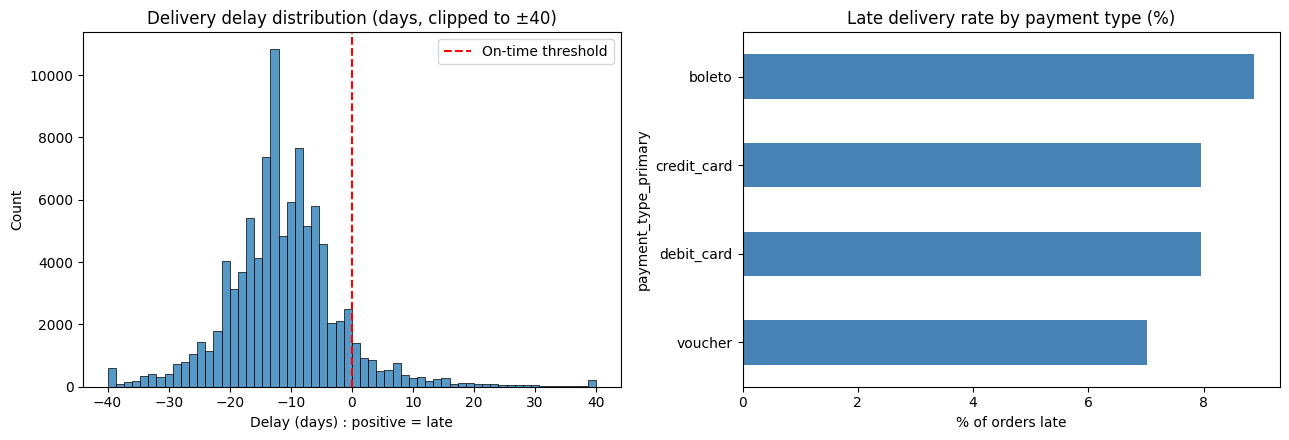

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.histplot(delivered['delivery_delay_days'].clip(-40, 40), bins=60, ax=axes[0])
axes[0].axvline(0, color='red', linestyle='--', label='On-time threshold')
axes[0].set_title('Delivery delay distribution (days, clipped to ±40)')
axes[0].set_xlabel('Delay (days) : positive = late')
axes[0].legend()

late_by_type = (delivered.groupby('payment_type_primary')['is_late'].mean() * 100).sort_values()
late_by_type.plot(kind='barh', ax=axes[1], color='steelblue')
axes[1].set_title('Late delivery rate by payment type (%)')
axes[1].set_xlabel('% of orders late')

plt.tight_layout()
plt.show()


## 6. Some questions to think about
- Should the binary `is_late` flag be used for the further analysis or the should a continuous `delivery_delay_days` be implemented, since the estimates are padded, magnitude may carry more signal than a simple late/not late split.

- Is the voucher cancellation pattern (2.79% vs ~0.5%) worth a dedicated chart, or too small a slice relative to other tracks' findings?

# 7. Deeper Analysis: Growth, Timing & Payment Patterns

The sections above check the order funnel and basic payment patterns.

This section does a deeper analysis by asking some more questions rather than just checking means and medians

In particular, it checks whether service quality has held up as order volume has grown, which is important to the project's main purpose of growing without breaking the experience.


## 7.1 Has delivery quality held up as order volume has grown?

This is the main question for this section, and the most direct link to the project's main business tension. Order volume by itself only tells a growth story but late rate and cancellation alongside it tells whether that growth came at a cost.

In [34]:
orders_master['purchase_month'] = pd.to_datetime(orders_master['purchase_ts']).dt.to_period('M').astype(str)

monthly = orders_master.groupby('purchase_month').agg(
    n_orders=('order_id', 'count'),
    pct_late=('is_late', 'mean'),
    pct_canceled=('is_canceled', 'mean')
).reset_index()

monthly

,purchase_month,n_orders,pct_late,pct_canceled
0,2016-09,4,0.250000,0.500000
1,2016-10,324,0.009259,0.074074
2,2016-12,1,0.000000,0.000000
3,2017-01,800,0.028750,0.003750
4,2017-02,1780,0.029775,0.009551
5,2017-03,2682,0.052946,0.012304
6,2017-04,2404,0.075291,0.007488
7,2017-05,3700,0.034595,0.007838
8,2017-06,3245,0.037288,0.004931
9,2017-07,4026,0.033035,0.006955


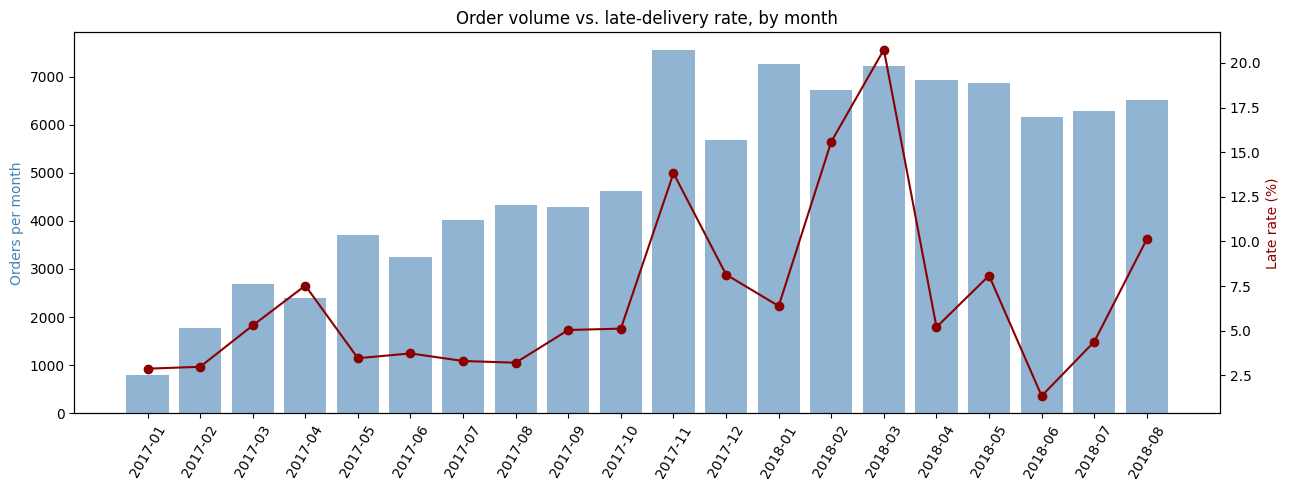

In [35]:
fig, ax1 = plt.subplots(figsize=(13, 5))

plot_data = monthly[(monthly['purchase_month'] >= '2017-01') & (monthly['purchase_month'] <= '2018-08')]

ax1.bar(plot_data['purchase_month'], plot_data['n_orders'], color='steelblue', alpha=0.6, label='Order volume')
ax1.set_ylabel('Orders per month', color='steelblue')
ax1.tick_params(axis='x', rotation=60)

ax2 = ax1.twinx()
ax2.plot(plot_data['purchase_month'], plot_data['pct_late'] * 100, color='darkred', marker='o', label='Late rate (%)')
ax2.set_ylabel('Late rate (%)', color='darkred')

ax1.set_title('Order volume vs. late-delivery rate, by month')
plt.tight_layout()
plt.show()


**Finding:** volume grows fairly steadily from a few hundred orders/month in early 2017 to 6,000 to 7,500/month by mid 2018 but late rate is far from flat alongside it.

- Two sharp spikes stand out: November 2017 (13.8% late, vs 5% in surrounding months) and March 2018 (20.7% late).

- November 2017 lines up with Black Friday in Brazil which might be a possible demand spike overwhelmed the logistics story.

- March 2018's spike is even larger and doesn't have as obvious an
explanation from this data alone.

**Important note:** The last two months in the raw data
(2018-09, 2018-10) show only 16 and 4 orders respectively, with ~94-100% cancellation.

- This is a dataset extraction boundary effect (orders placed too close to when the data was pulled never had time to complete normally), not a real decrease. So they are excluded from the chart above.

## 7.2 Approval time by payment type

The main sections above already show payment type barely affects lateness This asks a different, more basic operational question: does it affect how long payment approval itself takes? Which matters for the order funnel even before delivery enters the picture.

In [36]:
approval_by_type = delivered.groupby('payment_type_primary')['approval_hours'].agg(
    ['median', 'mean', 'count']
).round(2).sort_values('median', ascending=False)

approval_by_type

,median,mean,count
payment_type_primary,,,
boleto,29.06,33.01,19177
debit_card,0.84,9.12,1484
voucher,0.28,7.68,2977
credit_card,0.27,4.42,72825


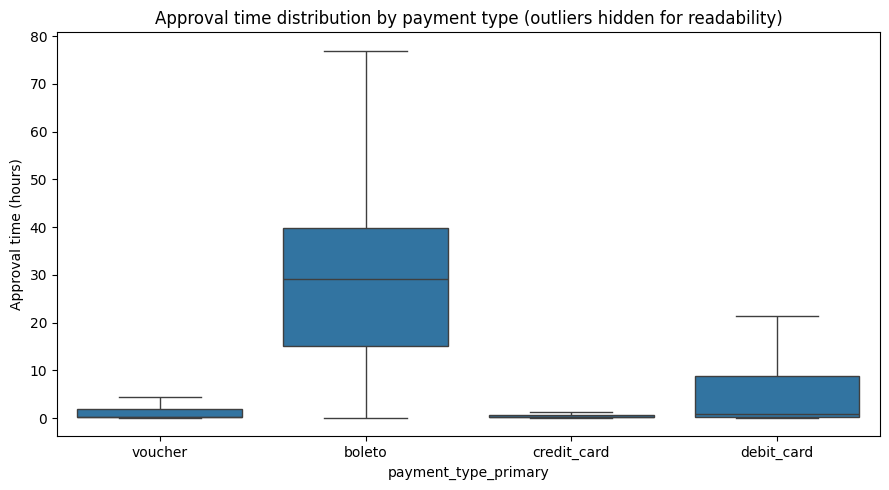

In [37]:
fig, ax = plt.subplots(figsize=(9, 5))
plot_types = ['boleto', 'credit_card', 'debit_card', 'voucher']
sns.boxplot(
    data=delivered[delivered['payment_type_primary'].isin(plot_types)],
    x='payment_type_primary', y='approval_hours', showfliers=False, ax=ax
)
ax.set_title('Approval time distribution by payment type (outliers hidden for readability)')
ax.set_ylabel('Approval time (hours)')
plt.tight_layout()
plt.show()

**Finding:** a large, well explained gap.

- Boleto's median approval time is 29 hours, versus under 1 hour for credit card, debit card, and voucher.

- This makes complete domain sense since boleto is a Brazilian bank slip payment method in which the customer has to actually go pay it (at a
bank, ATM, or via online banking) before it clears, unlike an instant card charge.

- Not a quality issue, an inherent property of the payment method so do not read it as an operational failure.

## 7.3 Split payment orders : checked, and mostly ruled out

Does paying across multiple installments/payment rows (`n_payment_rows > 1`) correlate with
order value, lateness, or cancellation?

In [38]:
orders_master['is_split_payment'] = orders_master['n_payment_rows'] > 1

split_compare = orders_master.groupby('is_split_payment').agg(
    n=('order_id', 'count'),
    avg_order_value=('total_payment_value', 'mean'),
    pct_late=('is_late', 'mean'),
    pct_canceled=('is_canceled', 'mean')
).round(3)

split_compare

,n,avg_order_value,pct_late,pct_canceled
is_split_payment,,,,
False,96480,160.830,0.079,0.006
True,2961,166.197,0.071,0.006


**Finding:** no meaningful difference (split payment orders are actually very slightly less late, 7.1% vs. 7.9%, and order value is similar).

- This is consistent with the pattern seen in other checks as well (payment type, installment count, seller size all similarly failed to predict lateness).

## 7.4 Voucher orders, one level deeper

Section 4.4 flagged voucher orders cancelling at 5-6x the rate of other payment types, without distinguishing between two explanations: a redemption/validation problem, or a different underlying customer profile. Two quick, cheap checks against that question.

In [39]:
print("Average and median order value by payment type:")
print(orders_master.groupby('payment_type_primary')['total_payment_value'].agg(['mean', 'median']).round(2))

Average and median order value by payment type:
                        mean  median
payment_type_primary                
boleto                145.03   93.89
credit_card           167.29  109.56
debit_card            142.72   89.30
not_defined             0.00    0.00
voucher               120.29   82.78


**Finding:** voucher orders average 120 Real, notably below credit card's 167 Real (both in R$) which is real evidence leaning toward the different customer profile explanation over redemption failures, since a validation failure story wouldn't obviously predict lower order value.

In [41]:
customers_available = False
try:
    customers = pd.read_csv('customers_dataset.csv')
    customers_available = True
except FileNotFoundError:
    print("customers_dataset.csv not found -- skipping the geographic check.")

if customers_available:
    merged_geo = orders_master.merge(customers[['customer_id', 'customer_state']], on='customer_id', how='left')
    top_states = merged_geo['customer_state'].value_counts().head(10).index

    voucher_share_by_state = (
        merged_geo[merged_geo['customer_state'].isin(top_states)]
        .groupby('customer_state')
        .apply(lambda g: (g['payment_type_primary'] == 'voucher').mean() * 100, include_groups=False)
        .sort_values(ascending=False)
    )
    print("Voucher share of orders, by state (top 10 states by volume):")
    print(voucher_share_by_state.round(2))

Voucher share of orders, by state (top 10 states by volume):
customer_state
BA    4.20
RJ    3.46
PR    3.29
SP    3.19
ES    3.10
MG    3.03
DF    2.85
GO    2.77
RS    2.74
SC    2.69
dtype: float64


**Finding:** flat across states (2.7% to 4.2%, no standout state)

- So this is checked and effectively ruled out as a geographic pattern.

- The order value difference above remains the more promising
lead; the cancellation rate question itself is still not fully resolved and should stay a documented candidate finding rather than a confident claim.

## 7.5 Add reusable columns to `orders_master.csv`

`purchase_month` and `is_split_payment` (built above) are broadly useful, and purely additive so safe to fold into the shared file directly rather than requiring them to be recomputed each time.

In [42]:
orders_master.to_csv('orders_master.csv', index=False)
print("Re-saved orders_master.csv with 2 new columns: purchase_month, is_split_payment")
print("Shape:", orders_master.shape)

Re-saved orders_master.csv with 2 new columns: purchase_month, is_split_payment
Shape: (99441, 21)


In [43]:
orders_master.head()

,order_id,customer_id,order_status,purchase_ts,approved_ts,carrier_ts,delivered_ts,estimated_delivery_ts,approval_hours,carrier_handoff_days,delivery_days,delivery_delay_days,is_delivered,is_canceled,is_late,total_payment_value,payment_type_primary,max_installments,n_payment_rows,purchase_month,is_split_payment
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,0.178333,2.366493,8.436574,-7.107488,True,False,False,38.71,voucher,1.0,3.0,2017-10,True
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,30.713889,0.462882,13.782037,-5.355729,True,False,False,141.46,boleto,1.0,1.0,2018-07,False
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,0.276111,0.204595,9.394213,-17.245498,True,False,False,179.12,credit_card,3.0,1.0,2018-08,False
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,0.298056,3.745833,13.208750,-12.980069,True,False,False,72.20,credit_card,1.0,1.0,2017-11,False
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,1.030556,0.893113,2.873877,-9.238171,True,False,False,28.62,credit_card,1.0,1.0,2018-02,False


## 7.6 More questions to think about

- The March 2018 late-rate spike (20.7%) doesn't have an obvious explanation from this data alone, can try searching about a cause and if not found then it should be presented as it is with the unexplained factor.

- Should the monthly volume vs quality chart (7.1) become one of the final presentation's anchor visuals, alongside Category D's delay vs review chart?

- Voucher's higher cancellation rate: still not fully explained. Worth a specific look once Category D's review data can test whether voucher paid orders that do complete also review worse, which would further support (or weaken) the different customer profile theory.